In [1]:
# 다중 클래스 분류 실습
'''
데이터 : wine dataset
클래스 : 3개
데이터 로드 > 학습 모델 설정 > 학습 > 핛급 결과 저장 > 성능 확인 > 신규 데이터 예측 > 결과 시각화
'''

'\n데이터 : wine dataset\n클래스 : 3개\n데이터 로드 > 학습 모델 설정 > 학습 > 핛급 결과 저장 > 성능 확인 > 신규 데이터 예측 > 결과 시각화\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine # 와인 데이터 읽어오기
import joblib # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 데이터 읽어오기(와인 데이터셋)
data = load_wine()
X = data.data
y = data.target

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)

df["target"] = y
print("전체 데이터 shape:", df.shape)

전체 데이터 shape: (178, 14)


In [4]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# one-hot 인코딩 수행 <-- 클래스별 확률 값에서 가장 큰 값을 1로 치환하고, 나머지는 0으로 치환하여 1의 결과를 반환
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [8]:
# 모델 정의
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_test_scaled.shape[1],)))   # 첫번째 은닉층 생성
model.add(Dropout(0.2))                                                          # 과적합 방지를 위한 드롭아웃 적용

model.add(Dense(32, activation="relu"))     # 두번째 은닉층 추가

model.add(Dense(3, activation="softmax"))   # 출력층은 클래스 3개, 활성화 함수는 softmax

model.summary()

D:\anaconda3\envs\ai\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,075 (12.01 KB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 모델 컴파일 설정
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience=10,
    restore_best_weights=True
)

In [10]:
# 모델 학습
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 334ms/step - accuracy: 0.6195 - loss: 0.9349 - val_accuracy: 0.7241 - val_loss: 0.8634
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8938 - loss: 0.7396 - val_accuracy: 0.8966 - val_loss: 0.7151
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9115 - loss: 0.6303 - val_accuracy: 0.9655 - val_loss: 0.5850
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9558 - loss: 0.5298 - val_accuracy: 1.0000 - val_loss: 0.4793
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9469 - loss: 0.4300 - val_accuracy: 1.0000 - val_loss: 0.3852
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9381 - loss: 0.3674 - val_accuracy: 1.0000 - val_loss: 0.3061
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9558 - loss: 0.3098 - val_accuracy: 1.0000 - val_loss: 0.2437
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9646 - loss: 0.2542 - val_accuracy: 1.0000 - val_lo

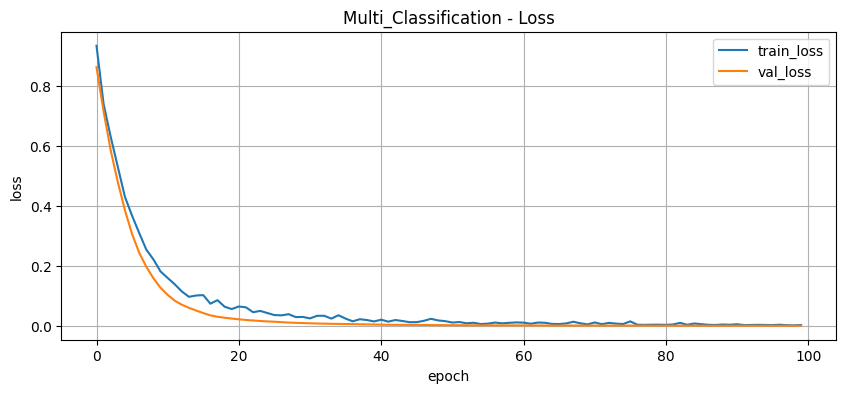

In [11]:
# 학습 Loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Multi_Classification - Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)   # 그래프를 격자로 표시
plt.show()

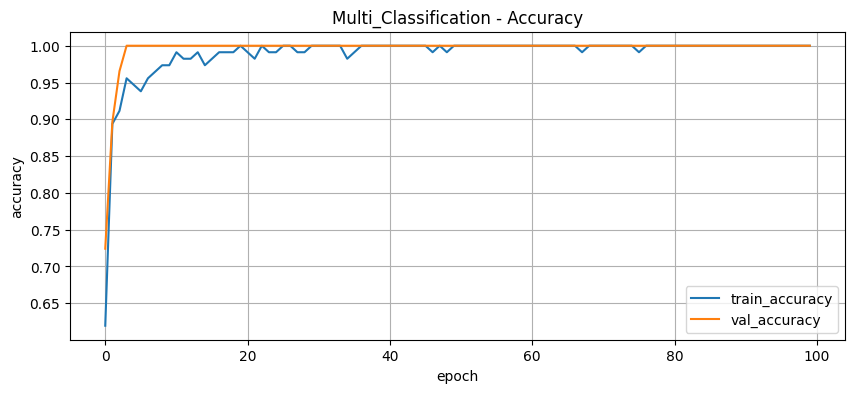

In [12]:
# 학습 Accuracy 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Multi_Classification - Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)   # 그래프를 격자로 표시
plt.show()

In [13]:
# 모델 평가 : 테스트 데이터에 대한 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

# 예측확률
y_prob = model.predict(X_test_scaled)

# 가장 확률이 높은 클래스를 선택
y_pred = np.argmax(y_prob, axis=1)

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# CM 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print("정확도:", acc)
print("confusion matrix: \n", cm)
print("분류 리포트 : \n", classification_report(y_test, y_pred))

테스트 손실:  0.07469800114631653
테스트 정확도:  0.9722222089767456
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 865ms/step
정확도: 0.9722222222222222
confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
분류 리포트 : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [19]:
# 학습 결과 저장

# 모델을 파일로 저장
model.save("./results/9-02) multiclass_model.h5")
# 스케일러 저장
joblib.dump(scaler, "./results/9-02) multiclass_model.pkl")
# 학습이력 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)
# 학습이력 저장
history_df.to_csv("./results/9-02) multiclass_model.csv", index=False)
print("저장 완료")

저장 완료


In [22]:
# 저장 결과 읽어오기
loaded_model = tf.keras.models.load_model("./results/9-02) multiclass_model.h5")
loaded_scaler = joblib.load("./results/9-02) multiclass_model.pkl")
loaded_scaler

,copy,True
,with_mean,True
,with_std,True


In [16]:
# 신규 데이터 예측 (추론)
'''
1. 신규 데이터 5행을 가져옴 (X_test)
   → 모델이 학습에 사용하지 않은 새로운 데이터를 선택

2. 학습 데이터와 스케일을 맞춤
   → 학습할 때 사용한 scaler로 transform 수행

3. 학습 결과 기반으로 신규데이터에 대해 예측 수행
   → model.predict()를 통해 각 클래스에 대한 확률 계산

4. X에 해당하는 클래스별 확률 계산
   → 예: [0.3, 0.1, 0.6] (A 30%, B 10%, C 60%)

5. 가장 높은 확률을 가진 클래스를 최종 결과로 선택
   → np.argmax()로 최대값의 인덱스를 선택
'''

new_data = X_test[:5]
new_data_scaled = loaded_scaler.transform(new_data)
new_prob = loaded_model.predict(new_data_scaled)
new_pred = np.argmax(new_prob, axis=1)

# 예측 결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측클래스: {new_pred[i]}, 클래스별 확률: {new_prob[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step
1번 샘플 - 예측클래스: 0, 클래스별 확률: [1.0000000e+00 5.5683245e-08 5.0994608e-08]
2번 샘플 - 예측클래스: 1, 클래스별 확률: [5.1784312e-04 8.8341618e-01 1.1606597e-01]
3번 샘플 - 예측클래스: 0, 클래스별 확률: [9.9998927e-01 7.0797778e-06 3.7394334e-06]
4번 샘플 - 예측클래스: 1, 클래스별 확률: [2.2254230e-01 7.7733952e-01 1.1819767e-04]
5번 샘플 - 예측클래스: 1, 클래스별 확률: [6.5747625e-04 9.9931276e-01 2.9732351e-05]


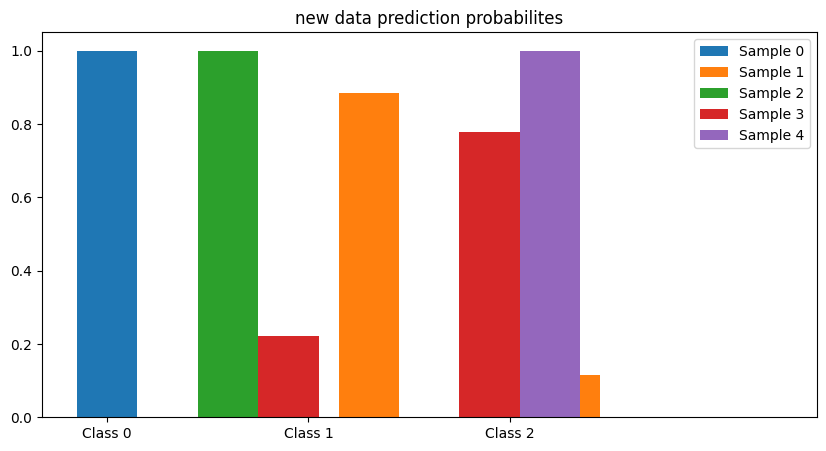

In [17]:
plt.figure(figsize=(10,5))
for i in range(len(new_prob)):
    plt.bar(
        np.arange(3) + i*0.3,
        new_prob[i],
        width=0.3,
        label=f"Sample {i}"
    )
plt.xticks([0,1,2], ["Class 0", "Class 1", "Class 2"])
plt.title("new data prediction probabilites")
plt.legend()
plt.show()